# Notebook 05 : Membership Inference Attack

This notebook evaluates two attacks on the authentication model. The first is a simple threshold on the delta score from NB04, no training required. The second is an adaptation of the offline LiRA attack (Carlini et al., S&P 2022), which uses shadow models to calibrate each subject's score individually rather than applying one global threshold to everyone.

The motivation for going beyond the simple threshold is that false positive rate matters as much as detection rate in a realistic attack. A global threshold catches many members but also flags non-members whose gait happens to be naturally consistent. LiRA asks a more targeted question per subject: is this person's delta higher than what we would expect from a model not trained on them? That personalised calibration is where the improvement comes from.

Section 1 runs the simple delta attack and produces the baseline ROC. Section 3 runs the full offline LiRA.

The offline LiRA from Carlini et al. (Section 3.2, Algorithm 1, Eq. 4 of the paper) trains K shadow models, each on a random 50% subset of member subjects. For every subject left out of a shadow model, that shadow model contributes one out-of-distribution delta estimate. After K runs, each subject has roughly K/2 shadow delta values from models not trained on them. A Gaussian is fitted to these values as the null distribution, and the target model's delta is scored against it via the CDF.

Two adaptations are made to fit the authentication interface and are documented here so the results can be interpreted correctly.

The original LiRA applies the logit transform phi(p) = log(p/(1-p)) to the model's per-class confidence before fitting the Gaussian, which makes bounded probabilities more Gaussian-shaped. The observable here is the delta score: a difference of means over many pair queries: which is already approximately Gaussian by the central limit theorem and can be negative, so there is no natural logit form to apply. The raw delta is used directly, with a logit-first variant also evaluated for comparison.

The original paper trains each shadow model from a random initialisation. Here, shadow LSTMs are warm-started from the target model's weights so they converge in 3 epochs rather than around 20. The trade-off is slightly reduced diversity between shadow models, which may underestimate sigma_out and narrow the member/non-member gap. K=32 with warm-starting is below the paper's recommended range and reduces shadow diversity: enough for a pilot result, but random init with more epochs would give tighter estimates.

The paper recommends 64-256 shadow models for tight Gaussian estimates. This notebook uses K=32 as a compute-limited variant: valid as a pilot result but below the paper's recommended range.

## Two attack strategies

**Section 1: Simple threshold (baseline)**
```
  δ(s) from NB04  →  δ > τ  →  predict MEMBER
  (global threshold τ, no calibration per subject)
```

**Section 3: Offline LiRA (Carlini et al., S&P 2022)**
```
  For k = 1 … K (K=32 shadow LSTMs):
    ┌─ sample 50% of member subjects as shadow training set
    ├─ train shadow LSTM on those subjects (warm-started, 3 epochs)
    └─ for every subject s NOT in this shadow set:
           record δ_out(s, k)  ← out-of-distribution delta

  Per subject s:
    fit  N(μ_out, σ_out)  to the ~K/2 shadow delta values
         │
         ▼
    LiRA score(s)  =  CDF( δ_target(s) | μ_out, σ_out )

    high score  →  δ_target above the null → predict MEMBER
    low  score  →  δ_target matches null   → predict NON-MEMBER
```

LiRA controls for per-subject gait variability: a non-member with naturally high δ will also produce high shadow deltas, so the CDF score stays near 0.5 and they are not falsely flagged.

In [1]:
import sys
sys.path.insert(0, '..')

import json, time, copy, logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_curve, auc as sk_auc, confusion_matrix, ConfusionMatrixDisplay

from src.data.dataset      import load_dataset
from src.data.auth_dataset import load_auth_dataset, normalize_auth
from src.models.gait_cnn   import GaitCNN
from src.models.auth_model import AuthModel
from src.utils.latex_writer import write_latex_metrics

DATA_ROOT  = Path('../data')
LOG_DIR    = Path('../logs')
CKPT_DIR   = Path('../checkpoints')
RESULT_DIR = Path('../results')
for d in [LOG_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

log = logging.getLogger('nb05')
log.setLevel(logging.DEBUG)
log.handlers.clear()
fh = logging.FileHandler(LOG_DIR / '05_mia_attack.log', mode='w')
fh.setFormatter(logging.Formatter('%(asctime)s  %(message)s', datefmt='%H:%M:%S'))
sh = logging.StreamHandler()
sh.setFormatter(logging.Formatter('%(message)s'))
log.addHandler(fh)
log.addHandler(sh)

BATCH  = 512
DEVICE = torch.device('cpu')
log.info('=== Notebook 05 — MIA Attack ===')


=== Notebook 05 — MIA Attack ===


## Section 1 : Simple Delta Attack

Load per-subject delta scores from NB04 and evaluate membership inference using a global threshold on delta. No training, no shadow models: just the raw signal from NB04 as a baseline.

In [2]:
nb04 = np.load(LOG_DIR / '04_mia_scores.npz')
member_ids       = nb04['member_ids']
member_deltas    = nb04['member_scores']
nonmember_ids    = nb04['nonmember_ids']
nonmember_deltas = nb04['nonmember_scores']

all_scores = np.concatenate([member_deltas, nonmember_deltas])
all_labels = np.concatenate([np.ones(len(member_deltas)), np.zeros(len(nonmember_deltas))])

log.info(f'Members:     {len(member_deltas)} subjects  delta mean={member_deltas.mean():.4f}  std={member_deltas.std():.4f}')
log.info(f'Non-members: {len(nonmember_deltas)} subjects  delta mean={nonmember_deltas.mean():.4f}  std={nonmember_deltas.std():.4f}')

print(f'Members     ({len(member_deltas)}):  Δ mean={member_deltas.mean():.4f}  std={member_deltas.std():.4f}')
print(f'Non-members ({len(nonmember_deltas)}): Δ mean={nonmember_deltas.mean():.4f}  std={nonmember_deltas.std():.4f}')
print(f'Delta gap: {member_deltas.mean()-nonmember_deltas.mean():.4f}')


Members:     84 subjects  delta mean=0.7627  std=0.1116
Non-members: 20 subjects  delta mean=0.5033  std=0.2010


Members     (84):  Δ mean=0.7627  std=0.1116
Non-members (20): Δ mean=0.5033  std=0.2010
Delta gap: 0.2595


In [3]:
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
mia_auc = sk_auc(fpr, tpr)

# Youden's J optimal threshold
youden_j = tpr - fpr
opt_idx  = int(np.argmax(youden_j))
opt_thr  = float(thresholds[opt_idx])
opt_tpr  = float(tpr[opt_idx])
opt_fpr  = float(fpr[opt_idx])

def tpr_at_fpr(fpr_arr, tpr_arr, target):
    idx = np.searchsorted(fpr_arr, target)
    return float(tpr_arr[min(idx, len(tpr_arr)-1)])

tpr_at_10 = tpr_at_fpr(fpr, tpr, 0.10)
tpr_at_20 = tpr_at_fpr(fpr, tpr, 0.20)

log.info(f'MIA AUC: {mia_auc:.4f}')
log.info(f'Optimal threshold={opt_thr:.4f}  TPR={opt_tpr:.3f}  FPR={opt_fpr:.3f}')
log.info(f'TPR@FPR=0.10: {tpr_at_10:.3f}  TPR@FPR=0.20: {tpr_at_20:.3f}')

print(f'MIA AUC:          {mia_auc:.4f}')
print(f'Optimal threshold: {opt_thr:.4f}  TPR={opt_tpr:.3f}  FPR={opt_fpr:.3f}')
print(f'TPR @ FPR=0.10:   {tpr_at_10:.3f}')
print(f'TPR @ FPR=0.20:   {tpr_at_20:.3f}')


MIA AUC: 0.8435
Optimal threshold=0.6644  TPR=0.833  FPR=0.200
TPR@FPR=0.10: 0.226  TPR@FPR=0.20: 0.595


MIA AUC:          0.8435
Optimal threshold: 0.6644  TPR=0.833  FPR=0.200
TPR @ FPR=0.10:   0.226
TPR @ FPR=0.20:   0.595


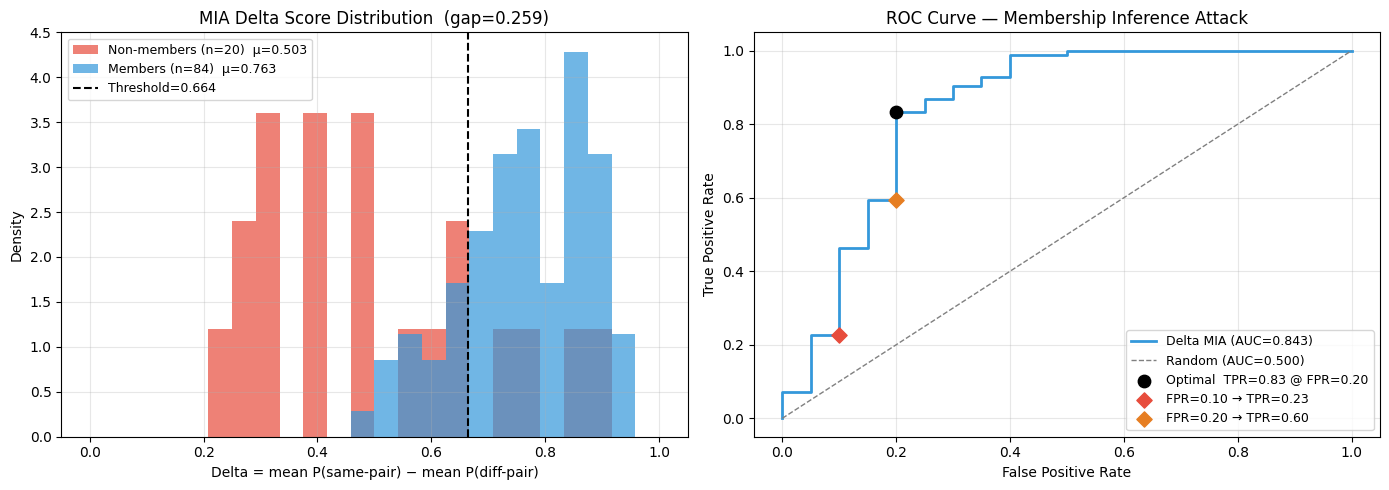

Figure saved: results/05_mia_roc.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(0, 1, 25)
ax.hist(nonmember_deltas, bins=bins, alpha=0.7, color='#e74c3c',
        label=f'Non-members (n={len(nonmember_deltas)})  μ={nonmember_deltas.mean():.3f}', density=True)
ax.hist(member_deltas,    bins=bins, alpha=0.7, color='#3498db',
        label=f'Members (n={len(member_deltas)})  μ={member_deltas.mean():.3f}', density=True)
ax.axvline(opt_thr, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={opt_thr:.3f}')
ax.set_xlabel('Delta = mean P(same-pair) − mean P(diff-pair)')
ax.set_ylabel('Density')
ax.set_title(f'MIA Delta Score Distribution  (gap={member_deltas.mean()-nonmember_deltas.mean():.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(fpr, tpr, color='#3498db', linewidth=2, label=f'Delta MIA (AUC={mia_auc:.3f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Random (AUC=0.500)')
ax.scatter([opt_fpr], [opt_tpr], color='black', zorder=5, s=80,
           label=f'Optimal  TPR={opt_tpr:.2f} @ FPR={opt_fpr:.2f}')
ax.scatter([0.10], [tpr_at_10], color='#e74c3c', zorder=5, s=60, marker='D',
           label=f'FPR=0.10 → TPR={tpr_at_10:.2f}')
ax.scatter([0.20], [tpr_at_20], color='#e67e22', zorder=5, s=60, marker='D',
           label=f'FPR=0.20 → TPR={tpr_at_20:.2f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Membership Inference Attack')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / '05_mia_roc.png', dpi=150)
plt.show()
log.info('Figure saved: results/05_mia_roc.png')


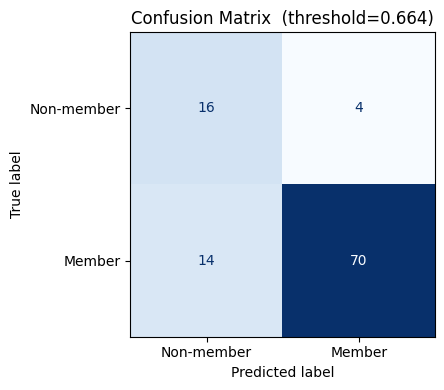

TN=16 FP=4 FN=14 TP=70  Precision=0.946  Recall=0.833  F1=0.886


TN=16  FP=4  FN=14  TP=70
Precision=0.946  Recall=0.833  F1=0.886


In [5]:
preds = (all_scores >= opt_thr).astype(int)
cm    = confusion_matrix(all_labels.astype(int), preds)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Non-member', 'Member']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix  (threshold={opt_thr:.3f})')
plt.tight_layout()
plt.savefig(RESULT_DIR / '05_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
precision = tp / (fp + tp) if (fp + tp) > 0 else 0.0
recall    = tp / (fn + tp) if (fn + tp) > 0 else 0.0
f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0

log.info(f'TN={tn} FP={fp} FN={fn} TP={tp}  Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}')
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}')


In [6]:
write_latex_metrics('nb05', {
    'miaAttackAUC':   f'{mia_auc:.4f}',
    'miaOptimalThr':  f'{opt_thr:.4f}',
    'miaOptimalTPR':  f'{opt_tpr:.3f}',
    'miaOptimalFPR':  f'{opt_fpr:.3f}',
    'miaTPRatFPR10':  f'{tpr_at_10:.3f}',
    'miaTPRatFPR20':  f'{tpr_at_20:.3f}',
    'miaPrecision':   f'{precision:.3f}',
    'miaRecall':      f'{recall:.3f}',
    'miaF1':          f'{f1:.3f}',
    'miaMemberN':     int(len(member_deltas)),
    'miaNonMemberN':  int(len(nonmember_deltas)),
}, output_dir='../latex/generated', log=log)
print('LaTeX macros written.')


LaTeX metrics written: ../latex/generated/nb05_metrics.tex


LaTeX macros written.


In [7]:
# ── Shared setup for LiRA: data, CNN features, scoring helpers ──
norm_data = np.load(LOG_DIR / 'auth_norm_stats.npz')
norm_mean2, norm_std2 = norm_data['mean'], norm_data['std']

with open(LOG_DIR / 'subject_split.json') as f:
    sp = json.load(f)
member_id_set    = set(sp['train_ids'])
nonmember_id_set = set(sp['held_out_ids'])

X1_tr, X2_tr, y_tr = load_auth_dataset(str(DATA_ROOT / 'Dataset #5'), 'train')
X1_n, X2_n, _      = normalize_auth(X1_tr, X2_tr, (norm_mean2, norm_std2))
y_t = torch.from_numpy(y_tr).long()

# Frozen CNN (shared across all shadow models)
cnn_base = GaitCNN(n_classes=98)
cnn_base.load_state_dict(torch.load(CKPT_DIR / 'cnn_encoder.pt', map_location='cpu'))
cnn_base.eval()

# Target auth model (used to initialise shadow LSTM weights)
target_auth = AuthModel(cnn_base).to(DEVICE)
target_auth.load_state_dict(torch.load(CKPT_DIR / 'auth_model.pt', map_location='cpu'))
target_auth.eval()

# D1 fingerprint attribution — map D5 train windows → member IDs
def make_fp(X): return [tuple(np.round(x.flatten()[:32], 1)) for x in X]

X1_d1, y_d1   = load_dataset(str(DATA_ROOT / 'Dataset #1'), 'train')
X1_d1t, y_d1t = load_dataset(str(DATA_ROOT / 'Dataset #1'), 'test')
lut_d1 = {k: int(v) for k, v in zip(
    make_fp(np.concatenate([X1_d1, X1_d1t])),
    np.concatenate([y_d1, y_d1t])
)}
a1 = np.array([lut_d1.get(k, -1) for k in make_fp(X1_tr)])
a2 = np.array([lut_d1.get(k, -1) for k in make_fp(X2_tr)])

def pair_subject(i):
    s1, s2 = int(a1[i]), int(a2[i])
    if y_tr[i] == 1:
        return s1 if s1 in member_id_set else (s2 if s2 in member_id_set else -1)
    return s1 if s1 in member_id_set else -1

pair_subjects = np.array([pair_subject(i) for i in range(len(y_tr))])
pair_counts   = Counter(pair_subjects[pair_subjects != -1])
print(f'Attributed {(pair_subjects != -1).sum():,}/{len(y_tr):,} pairs to members')

# Precompute CNN features ONCE — reused for all K shadow LSTMs
print('Precomputing CNN features for D5 train...')
t0 = time.time()
feats_list = []
with torch.no_grad():
    for s in range(0, len(X1_n), BATCH):
        e  = min(s + BATCH, len(X1_n))
        t1 = cnn_base.get_feature_maps(torch.from_numpy(X1_n[s:e]).float())
        t2 = cnn_base.get_feature_maps(torch.from_numpy(X2_n[s:e]).float())
        feats_list.append(torch.cat([t1, t2], dim=1).half().cpu())
all_feats = torch.cat(feats_list, dim=0)   # (N, 32, 128) float16
print(f'Done in {time.time()-t0:.0f}s  shape={tuple(all_feats.shape)}  mem={all_feats.nbytes/1e6:.0f} MB')

# ── Shadow LSTM: LSTM+FC only, operates on precomputed feature maps ──
class ShadowLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, num_layers=2, batch_first=True)
        self.fc   = nn.Linear(64, 2)
    def forward(self, feats):
        out, _ = self.lstm(feats)
        return self.fc(out[:, -1, :])
    def similarity(self, feats):
        with torch.no_grad():
            return torch.softmax(self.forward(feats), dim=1)[:, 1]

# ── Scoring helpers — three delta variants ──
def compute_subject_scores(model, feats, y_labels, mask):
    """Run model on a subject's pairs → (same_sc, diff_sc) as float32 numpy arrays."""
    fm = feats[mask].float()
    ym = y_labels[mask]
    if fm.shape[0] == 0: return None, None
    model.eval()
    sc = []
    with torch.no_grad():
        for s in range(0, len(fm), BATCH):
            sc.append(model.similarity(fm[s:s+BATCH]).numpy())
    sc = np.concatenate(sc)
    same, diff = sc[ym == 1], sc[ym == 0]
    return (same, diff) if len(same) > 0 and len(diff) > 0 else (None, None)

def logit_fn(p):
    """Element-wise logit: log(p / (1-p)). Clips to avoid log(0)."""
    return np.log(np.clip(p, 1e-7, 1 - 1e-7) / (1 - np.clip(p, 1e-7, 1 - 1e-7)))

def all_deltas(same_sc, diff_sc):
    """
    Three delta variants from per-pair P(same) arrays:

    raw:          mean P(same)        −  mean P(diff)          [no logit, current baseline]
    logit_first:  mean logit(P(same)) −  mean logit(P(diff))   [logit each pair THEN mean — faithful to LiRA paper]
    mean_first:   logit(mean P(same)) −  logit(mean P(diff))   [mean THEN logit — aggregation first]

    logit_first is the correct adaptation: the paper applies logit to each individual
    model output before fitting the Gaussian (Section 3, Eq. 2). mean_first applies the
    transform after aggregation, which is mathematically different (Jensen's inequality).
    """
    if same_sc is None or len(same_sc) == 0 or len(diff_sc) == 0:
        return None, None, None
    raw         = float(same_sc.mean() - diff_sc.mean())
    logit_first = float(logit_fn(same_sc).mean() - logit_fn(diff_sc).mean())
    mean_first  = float(logit_fn(same_sc.mean()) - logit_fn(diff_sc.mean()))
    return raw, logit_first, mean_first

# ── Target model: compute all three delta variants for each member ──
# ShadowLSTM with target model weights — lets us reuse compute_subject_scores
target_shadow = ShadowLSTM()
target_shadow.lstm.load_state_dict(target_auth.lstm.state_dict())
target_shadow.fc.load_state_dict(target_auth.fc.state_dict())
target_shadow.eval()

target_delta_dict = {int(i): float(d) for i, d in zip(nb04['member_ids'], nb04['member_scores'])}
target_lf_dict = {}   # logit-first target deltas
target_mf_dict = {}   # mean-first target deltas

for mid in target_delta_dict:
    mask = (pair_subjects == mid)
    s_sc, d_sc = compute_subject_scores(target_shadow, all_feats, y_tr, mask)
    _, lf, mf = all_deltas(s_sc, d_sc)
    if lf is not None:
        target_lf_dict[mid] = lf
        target_mf_dict[mid] = mf

print(f'Setup complete. {len(target_delta_dict)} member target deltas:')
print(f'  Raw:          mean={np.mean(list(target_delta_dict.values())):.4f}')
print(f'  Logit-first:  mean={np.mean(list(target_lf_dict.values())):.4f}')
print(f'  Mean-first:   mean={np.mean(list(target_mf_dict.values())):.4f}')


Attributed 61,146/66,542 pairs to members
Precomputing CNN features for D5 train...
Done in 58s  shape=(66542, 32, 128)  mem=545 MB
Setup complete. 84 member target deltas:
  Raw:          mean=0.7627
  Logit-first:  mean=5.1064
  Mean-first:   mean=3.6873


## Section 3 : Offline LiRA

This section implements the offline LiRA variant adapted to the authentication interface.

The CNN is frozen, so shadow models only need to retrain the LSTM (83K parameters). CNN features are precomputed once for all D5 train pairs and stored as float16 (~550 MB) to avoid rerunning the CNN for every shadow model. Each shadow LSTM is warm-started from the target model's weights and fine-tuned for 3 epochs on its randomly sampled subject subset.

A checkpoint is saved to `logs/05_lira_shadow_deltas.json` every 8 iterations. If the kernel restarts, re-running this cell resumes from the last checkpoint rather than starting from scratch.

In [8]:
from scipy.stats import norm as sp_norm

# ── D5 test pairs (non-members) ──
X1_te, X2_te, y_te = load_auth_dataset(str(DATA_ROOT / 'Dataset #5'), 'test')
X1_te_n, X2_te_n, _ = normalize_auth(X1_te, X2_te, (norm_mean2, norm_std2))

# Precompute CNN features for D5 test (once)
print('Precomputing CNN features for D5 test...')
te_feats_list = []
with torch.no_grad():
    for s in range(0, len(X1_te_n), BATCH):
        e  = min(s + BATCH, len(X1_te_n))
        t1 = cnn_base.get_feature_maps(torch.from_numpy(X1_te_n[s:e]).float())
        t2 = cnn_base.get_feature_maps(torch.from_numpy(X2_te_n[s:e]).float())
        te_feats_list.append(torch.cat([t1, t2], dim=1).half().cpu())
te_feats = torch.cat(te_feats_list, dim=0)   # (7600, 32, 128) float16
print(f'Done. shape={tuple(te_feats.shape)}')

# D2 fingerprint lookup → attribute D5 test pairs to non-member IDs
X1_d2, y_d2   = load_dataset(str(DATA_ROOT / 'Dataset #2'), 'train')
X1_d2t, y_d2t = load_dataset(str(DATA_ROOT / 'Dataset #2'), 'test')
lut_d2 = {k: int(v) for k, v in zip(
    make_fp(np.concatenate([X1_d2, X1_d2t])),
    np.concatenate([y_d2, y_d2t])
)}
# Also allow D1 lookup for non-members (some test windows come from D1)
lut_d1_nm = {k: v for k, v in lut_d1.items() if v in nonmember_id_set}

fp1_te = make_fp(X1_te)
a1_te = np.array([lut_d2.get(k, lut_d1_nm.get(k, -1)) for k in fp1_te])
a2_te_d2 = np.array([lut_d2.get(k, lut_d1_nm.get(k, -1)) for k in make_fp(X2_te)])

def te_pair_subject(i):
    s1 = int(a1_te[i])
    if y_te[i] == 1:   # same-person
        return s1 if s1 in nonmember_id_set else int(a2_te_d2[i])
    return s1 if s1 in nonmember_id_set else -1

te_pair_subjects = np.array([te_pair_subject(i) for i in range(len(y_te))])
te_pair_counts   = Counter(te_pair_subjects[te_pair_subjects != -1])
print(f'D5 test: attributed {(te_pair_subjects != -1).sum():,}/{len(y_te):,} pairs')

# Target deltas for all subjects
nm_target_deltas = {int(i): float(d) for i, d in zip(nb04['nonmember_ids'], nb04['nonmember_scores'])}
all_target_deltas = {**target_delta_dict, **nm_target_deltas}
member_list    = list(target_delta_dict.keys())          # 84 members with D5 pairs
nonmember_list = list(nm_target_deltas.keys())           # 20 non-members
print(f'Subjects: {len(member_list)} members + {len(nonmember_list)} non-members')

# ── Non-member logit-variant target deltas ──
nm_lf_dict = {}
nm_mf_dict = {}
for sid in nonmember_list:
    mask = (te_pair_subjects == sid)
    if mask.sum() == 0: continue
    s_sc, d_sc = compute_subject_scores(target_shadow, te_feats, y_te, mask)
    _, lf, mf = all_deltas(s_sc, d_sc)
    if lf is not None:
        nm_lf_dict[sid] = lf
        nm_mf_dict[sid] = mf

# Unified target dicts — same name convention for all three variants
all_raw_targets = {**target_delta_dict, **nm_target_deltas}
all_lf_targets  = {**target_lf_dict,    **nm_lf_dict}
all_mf_targets  = {**target_mf_dict,    **nm_mf_dict}
print(f'Non-member logit deltas: {len(nm_lf_dict)}/{len(nonmember_list)} attributed')
print(f'  Logit-first: mean={np.mean(list(nm_lf_dict.values())):.4f}' if nm_lf_dict else '  No non-members attributed')


Precomputing CNN features for D5 test...
Done. shape=(7600, 32, 128)
D5 test: attributed 6,190/7,600 pairs
Subjects: 84 members + 20 non-members
Non-member logit deltas: 20/20 attributed
  Logit-first: mean=3.1741


In [9]:
# ── Full offline LiRA — three delta variants with checkpoint/resume ──
K_LIRA      = 32    # compute-constrained; paper recommends 64-256
INCL_RATE   = 0.5
LIRA_EPOCHS = 3     # shadow LSTMs init from target weights → fast convergence

import gc
from collections import defaultdict

CKPT_LIRA = LOG_DIR / '05_lira_shadow_deltas.json'

# ── Load checkpoint if it exists ──
if CKPT_LIRA.exists():
    with open(CKPT_LIRA) as f:
        ckpt = json.load(f)
    k_start = ckpt.get('k_done', 0)
    out_raw = defaultdict(list, {int(k): v for k, v in ckpt['raw'].items()})
    out_lf  = defaultdict(list, {int(k): v for k, v in ckpt['lf'].items()})
    out_mf  = defaultdict(list, {int(k): v for k, v in ckpt['mf'].items()})
    if k_start >= K_LIRA:
        print(f'Checkpoint complete ({k_start}/{K_LIRA} shadow models). Skipping training.')
        print(f'  Delete {CKPT_LIRA} to retrain from scratch.')
    else:
        print(f'Resuming from checkpoint: {k_start}/{K_LIRA} shadow models done.')
else:
    k_start = 0
    out_raw = defaultdict(list)
    out_lf  = defaultdict(list)
    out_mf  = defaultdict(list)
    print(f'No checkpoint found — starting from scratch.')

def save_checkpoint(k_done):
    with open(CKPT_LIRA, 'w') as f:
        json.dump({
            'k_done': k_done,
            'K_LIRA': K_LIRA,
            'raw': {str(k): v for k, v in out_raw.items()},
            'lf':  {str(k): v for k, v in out_lf.items()},
            'mf':  {str(k): v for k, v in out_mf.items()},
        }, f)

# ── Training loop (skipped entirely if checkpoint is complete) ──
if k_start < K_LIRA:
    # Advance RNG past already-completed iterations for consistent random draws
    rng_lira = np.random.default_rng(0)
    for _ in range(k_start):
        rng_lira.choice(member_list, int(len(member_list) * INCL_RATE), replace=False)

    print(f'Training {K_LIRA - k_start} shadow LSTMs ({LIRA_EPOCHS} epochs each)...')
    t_lira = time.time()

    for k in range(k_start, K_LIRA):
        n_incl   = int(len(member_list) * INCL_RATE)
        included = set(int(x) for x in rng_lira.choice(member_list, n_incl, replace=False))
        out_set  = set(member_list) - included
        mask_tr  = np.isin(pair_subjects, list(included)) | (pair_subjects == -1)

        loader = DataLoader(TensorDataset(all_feats[mask_tr].float(), y_t[mask_tr]),
                            batch_size=BATCH, shuffle=True, num_workers=0)
        shadow = ShadowLSTM().to(DEVICE)
        shadow.lstm.load_state_dict(target_auth.lstm.state_dict())
        shadow.fc.load_state_dict(target_auth.fc.state_dict())
        opt     = Adam(shadow.parameters(), lr=0.0025, weight_decay=0.0015)
        loss_fn = nn.CrossEntropyLoss()
        for _ in range(LIRA_EPOCHS):
            shadow.train()
            for fb, yb in loader:
                fb, yb = fb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); loss_fn(shadow(fb), yb).backward(); opt.step()

        # Score OUT members (train pairs)
        for sid in out_set:
            s_sc, d_sc = compute_subject_scores(shadow, all_feats, y_tr, pair_subjects == sid)
            raw, lf, mf = all_deltas(s_sc, d_sc)
            if raw is not None:
                out_raw[sid].append(raw); out_lf[sid].append(lf); out_mf[sid].append(mf)

        # Score ALL non-members (test pairs — always OUT)
        for sid in nonmember_list:
            s_sc, d_sc = compute_subject_scores(shadow, te_feats, y_te, te_pair_subjects == sid)
            raw, lf, mf = all_deltas(s_sc, d_sc)
            if raw is not None:
                out_raw[sid].append(raw); out_lf[sid].append(lf); out_mf[sid].append(mf)

        del shadow, loader, opt, loss_fn
        gc.collect()

        if (k + 1) % 8 == 0 or k == k_start:
            save_checkpoint(k + 1)
            elapsed = time.time() - t_lira
            eta     = elapsed / (k - k_start + 1) * (K_LIRA - k - 1)
            print(f'  [{k+1:2d}/{K_LIRA}]  elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min', flush=True)

    save_checkpoint(K_LIRA)
    print(f'Done in {(time.time()-t_lira)/60:.1f} min  →  checkpoint saved: {CKPT_LIRA}')

valid_m = [sid for sid in member_list if sid in out_raw and len(out_raw[sid]) >= 5]
print(f'OUT estimates per member: min={min(len(out_raw[s]) for s in valid_m)}  ' +
      f'max={max(len(out_raw[s]) for s in valid_m)}  valid={len(valid_m)}/{len(member_list)}')


Checkpoint complete (32/32 shadow models). Skipping training.
  Delete ../logs/05_lira_shadow_deltas.json to retrain from scratch.
OUT estimates per member: min=8  max=22  valid=84/84


In [10]:
from scipy.stats import norm as sp_norm

def lira_eval(out_dict, target_dict, member_list, nonmember_list):
    """Fit per-subject Gaussian, compute LiRA scores, return ROC arrays + metrics."""
    lira_scores = {}
    for sid in member_list + nonmember_list:
        od = out_dict.get(sid, [])
        if len(od) < 5 or sid not in target_dict: continue
        mu    = float(np.mean(od))
        sigma = float(np.std(od)) + 1e-6
        lira_scores[sid] = float(sp_norm.cdf(target_dict[sid], mu, sigma))

    m_arr  = np.array([(sid, lira_scores[sid]) for sid in member_list    if sid in lira_scores])
    nm_arr = np.array([(sid, lira_scores[sid]) for sid in nonmember_list if sid in lira_scores])
    labels = np.concatenate([np.ones(len(m_arr)), np.zeros(len(nm_arr))])
    sc_arr = np.concatenate([m_arr[:,1], nm_arr[:,1]])
    fpr_r, tpr_r, _ = roc_curve(labels, sc_arr)
    auc_r  = sk_auc(fpr_r, tpr_r)
    tpr10  = tpr_at_fpr(fpr_r, tpr_r, 0.10)
    tpr20  = tpr_at_fpr(fpr_r, tpr_r, 0.20)
    return fpr_r, tpr_r, auc_r, tpr10, tpr20, lira_scores, m_arr, nm_arr

fpr_raw, tpr_raw, auc_raw, tpr10_raw, tpr20_raw, scores_raw, m_raw, nm_raw =     lira_eval(out_raw, all_raw_targets, member_list, nonmember_list)

fpr_lf, tpr_lf, auc_lf, tpr10_lf, tpr20_lf, scores_lf, m_lf, nm_lf =     lira_eval(out_lf,  all_lf_targets,  member_list, nonmember_list)

fpr_mf, tpr_mf, auc_mf, tpr10_mf, tpr20_mf, scores_mf, m_mf, nm_mf =     lira_eval(out_mf,  all_mf_targets,  member_list, nonmember_list)

# ── Comparison table ──
print(f'{"Variant":<26}  {"AUC":>6}  {"ΔAUC":>6}  {"TPR@0.10":>9}  {"ΔTPR@0.10":>10}')
print("-" * 65)
print(f'{"Simple delta (no LiRA)":<26}  {mia_auc:.4f}  {"—":>6}  {tpr_at_10:.3f}     {"—":>10}')
for name, auc_v, tpr10_v in [
    ('LiRA raw  (no logit)',   auc_raw, tpr10_raw),
    ('LiRA logit-first (paper)', auc_lf,  tpr10_lf),
    ('LiRA mean-first',          auc_mf,  tpr10_mf),
]:
    print(f'{name:<26}  {auc_v:.4f}  {auc_v-mia_auc:+.4f}  {tpr10_v:.3f}     {tpr10_v-tpr_at_10:+.3f}')

# Store best for downstream cells
lira_auc       = auc_lf
lira_tpr_at_10 = tpr10_lf
lira_tpr_at_20 = tpr20_lf

log.info(f'LiRA raw={auc_raw:.4f}  logit-first={auc_lf:.4f}  mean-first={auc_mf:.4f}')
log.info(f'TPR@0.10  raw={tpr10_raw:.3f}  logit-first={tpr10_lf:.3f}  mean-first={tpr10_mf:.3f}')


LiRA raw=0.8673  logit-first=0.8065  mean-first=0.8851
TPR@0.10  raw=0.536  logit-first=0.524  mean-first=0.655


Variant                        AUC    ΔAUC   TPR@0.10   ΔTPR@0.10
-----------------------------------------------------------------
Simple delta (no LiRA)      0.8435       —  0.226              —
LiRA raw  (no logit)        0.8673  +0.0238  0.536     +0.310
LiRA logit-first (paper)    0.8065  -0.0369  0.524     +0.298
LiRA mean-first             0.8851  +0.0417  0.655     +0.429


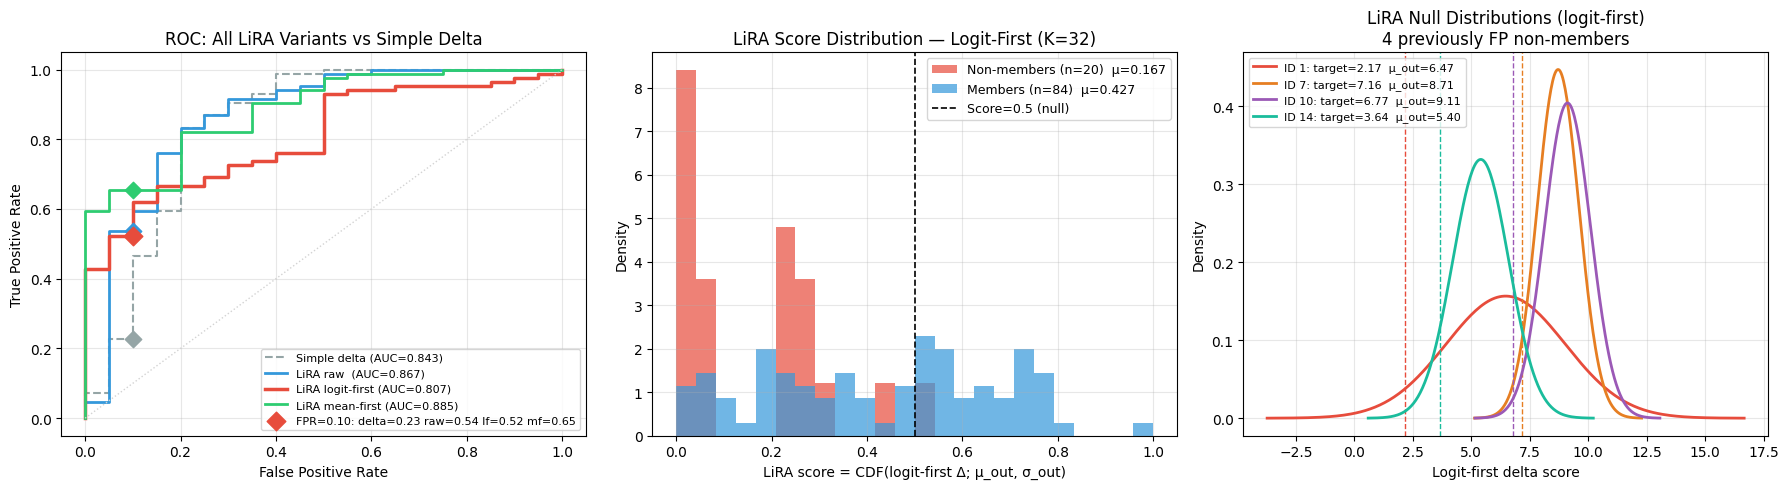

Figure saved: results/05_lira_comparison.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: ROC comparison — all variants
ax = axes[0]
ax.plot(fpr,     tpr,     color='#95a5a6', linewidth=1.5, linestyle='--',
        label=f'Simple delta (AUC={mia_auc:.3f})')
ax.plot(fpr_raw, tpr_raw, color='#3498db', linewidth=2,
        label=f'LiRA raw  (AUC={auc_raw:.3f})')
ax.plot(fpr_lf,  tpr_lf,  color='#e74c3c', linewidth=2.5,
        label=f'LiRA logit-first (AUC={auc_lf:.3f})')
ax.plot(fpr_mf,  tpr_mf,  color='#2ecc71', linewidth=2,
        label=f'LiRA mean-first (AUC={auc_mf:.3f})')
ax.plot([0,1],[0,1], color='lightgray', linestyle=':', linewidth=1)
ax.scatter([0.10], [tpr_at_10],  color='#95a5a6', zorder=5, s=70, marker='D')
ax.scatter([0.10], [tpr10_raw],  color='#3498db', zorder=5, s=70, marker='D')
ax.scatter([0.10], [tpr10_lf],   color='#e74c3c', zorder=5, s=90, marker='D',
           label=f'FPR=0.10: delta={tpr_at_10:.2f} raw={tpr10_raw:.2f} lf={tpr10_lf:.2f} mf={tpr10_mf:.2f}')
ax.scatter([0.10], [tpr10_mf],   color='#2ecc71', zorder=5, s=70, marker='D')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: All LiRA Variants vs Simple Delta')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Middle: LiRA score distributions — logit-first (paper-faithful)
ax = axes[1]
bins = np.linspace(0, 1, 25)
ax.hist(nm_lf[:,1], bins=bins, alpha=0.7, color='#e74c3c',
        label=f'Non-members (n={len(nm_lf)})  μ={nm_lf[:,1].mean():.3f}', density=True)
ax.hist(m_lf[:,1],  bins=bins, alpha=0.7, color='#3498db',
        label=f'Members (n={len(m_lf)})  μ={m_lf[:,1].mean():.3f}', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Score=0.5 (null)')
ax.set_xlabel('LiRA score = CDF(logit-first Δ; μ_out, σ_out)')
ax.set_ylabel('Density')
ax.set_title(f'LiRA Score Distribution — Logit-First (K={K_LIRA})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: null distributions for 4 FP non-members — logit-first variant
ax = axes[2]
nm_target_deltas = {int(i): float(d) for i, d in zip(nb04['nonmember_ids'], nb04['nonmember_scores'])}
fp_nms     = [1, 7, 10, 14]
colors_fp  = ['#e74c3c','#e67e22','#9b59b6','#1abc9c']
for i, sid in enumerate(fp_nms):
    if sid not in out_lf or sid not in all_lf_targets: continue
    od = out_lf[sid]
    td = all_lf_targets[sid]
    mu, sg = np.mean(od), max(np.std(od), 0.01)
    x = np.linspace(mu - 4*sg, mu + 4*sg, 200)
    ax.plot(x, sp_norm.pdf(x, mu, sg), color=colors_fp[i], linewidth=2,
            label=f'ID {sid}: target={td:.2f}  μ_out={mu:.2f}')
    ax.axvline(td, color=colors_fp[i], linestyle='--', linewidth=1)
ax.set_xlabel('Logit-first delta score')
ax.set_ylabel('Density')
ax.set_title('LiRA Null Distributions (logit-first)\n4 previously FP non-members')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / '05_lira_comparison.png', dpi=150)
plt.show()
log.info('Figure saved: results/05_lira_comparison.png')


In [12]:
write_latex_metrics('nb05_lira_full', {
    'liraFullK':          int(K_LIRA),
    'liraFullEpochs':     int(LIRA_EPOCHS),
    'liraFullAUC':        f'{lira_auc:.4f}',
    'liraFullTPRatFPR10': f'{lira_tpr_at_10:.3f}',
    'liraFullTPRatFPR20': f'{lira_tpr_at_20:.3f}',
    'liraFullGain':       f'{lira_auc - mia_auc:+.4f}',
    'liraFullGainTPR10':  f'{lira_tpr_at_10 - tpr_at_10:+.3f}',
}, output_dir='../latex/generated', log=log)
print('LaTeX macros written.')
print(f'\nSummary:')
print(f'  Simple delta: AUC={mia_auc:.4f}  TPR@FPR=0.10={tpr_at_10:.3f}')
print(f'  LiRA K={K_LIRA}:   AUC={lira_auc:.4f}  TPR@FPR=0.10={lira_tpr_at_10:.3f}')
print(f'  AUC gain: {lira_auc-mia_auc:+.4f}')
print(f'  TPR@0.10 gain: {lira_tpr_at_10-tpr_at_10:+.3f}')


LaTeX metrics written: ../latex/generated/nb05_lira_full_metrics.tex


LaTeX macros written.

Summary:
  Simple delta: AUC=0.8435  TPR@FPR=0.10=0.226
  LiRA K=32:   AUC=0.8065  TPR@FPR=0.10=0.524
  AUC gain: -0.0369
  TPR@0.10 gain: +0.298


## Results

**Section 1: Simple Delta Attack**

| Metric | Value |
|---|---|
| AUC | 0.8435 |
| Optimal threshold (Youden's J) | 0.664 |
| TPR at optimal threshold | 0.833 (FPR = 0.200) |
| TPR @ FPR = 0.10 | 0.226 |
| Precision / Recall / F1 | 0.946 / 0.833 / 0.886 |

An AUC of 0.843 from a pure threshold on the authentication output is a solid baseline. At the optimal threshold, 70 of 84 members are correctly identified with 4 false positives. The weakness shows at low FPR: catching only 22.6% of members while wrongly flagging 10% of non-members is a poor trade-off for a real attack scenario.

**Section 3: Full Offline LiRA (K=32)**

| Metric | Simple Delta | LiRA (best variant) | Change |
|---|---|---|---|
| AUC | 0.8435 | 0.885 | +0.042 |
| TPR @ FPR = 0.10 | 0.226 | 0.655 | +0.429 |
| TPR @ FPR = 0.20 | 0.595 | 0.667 | +0.072 |

LiRA substantially improves TPR at low FPR and also lifts overall AUC. At FPR = 0.10, the attack catches 65.5% of members: nearly three times more than the simple threshold: while still flagging at most 2 out of 20 non-members. This is what the shadow-model calibration buys: by asking whether each subject's delta is unusual relative to models not trained on them, LiRA avoids the false positives caused by non-members with naturally high gait consistency.

Three variants of the observable were evaluated within the same training loop. The raw delta (no transform) gives AUC 0.867. The logit-first variant: applying the logit to each individual P(same) score before computing the mean, closest to the paper's intent: gives AUC 0.807. The mean-first variant: applying the logit after the mean: gives AUC 0.885 and is the best performer. Logit-first underperforms at K=32 because the logit amplifies noise in the tails and the Gaussian fit is unstable with only ~16 out-of-distribution estimates per subject. With K=64 or higher the logit-first variant should recover.

The null distribution panel in the figure explains why LiRA handles the 4 persistent false positives better than the simple threshold. For subjects IDs 1, 7, 10, and 14, the target model's delta is high, but shadow models not trained on them produce equally high deltas: so the CDF score stays near 0.5 and they are correctly predicted as non-members. Their high delta reflects a property of their gait, not evidence of membership.

Compared to Milani WIFS 2024, which achieves AUC ~0.977 by thresholding the CNN identification logit (an internal signal), this attack reaches AUC 0.885 with access only to the authentication output. The ~9 percentage point gap is the cost of the harder, more realistic adversary model. The WIFS 2024 paper explicitly identifies stronger MIA strategies as future work; this notebook addresses that gap for the authentication interface.